# Time Series analysis on the data International Airline passengers from 1940 to 1960

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
from  statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
# data fetch from github
df = pd.read_csv('Airline-passengers.csv')
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df.shape

(144, 2)

In [5]:
df.isnull().sum()

Month         0
Passengers    0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


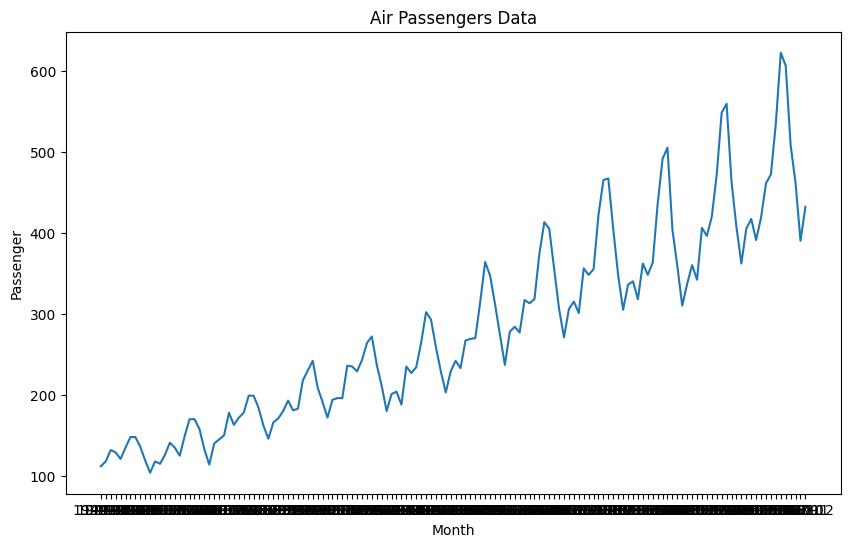

In [7]:
# plot this data to see trends and seasonality
plt.figure(figsize=(10,6))
plt.plot(df['Month'], df['Passengers'])
plt.xlabel('Month')
plt.ylabel('Passenger')
plt.title('Air Passengers Data')
plt.show()

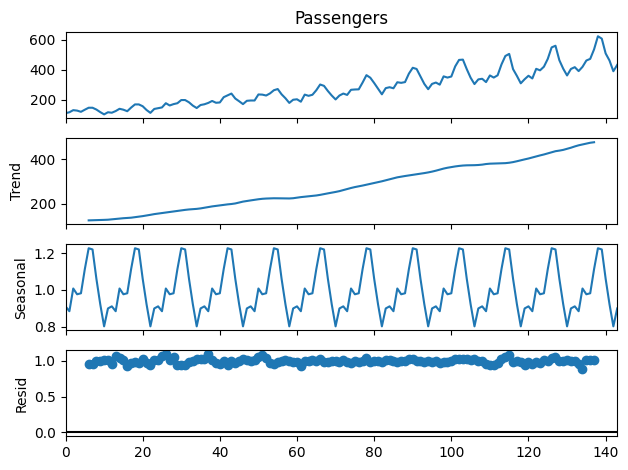

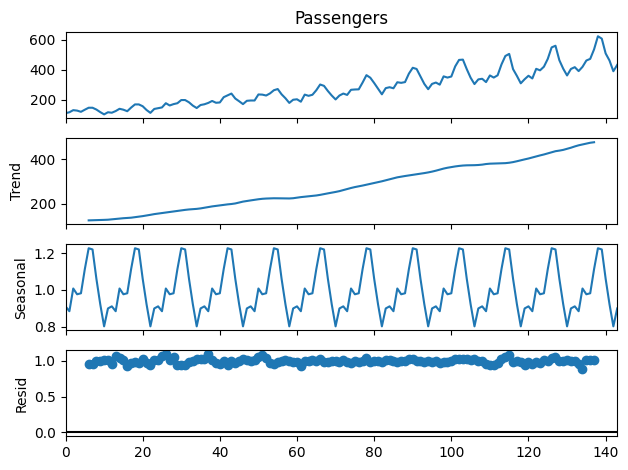

In [8]:
# Decompose the data into trends seasonality and residuals
decompose = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)
decompose.plot()

<Axes: >

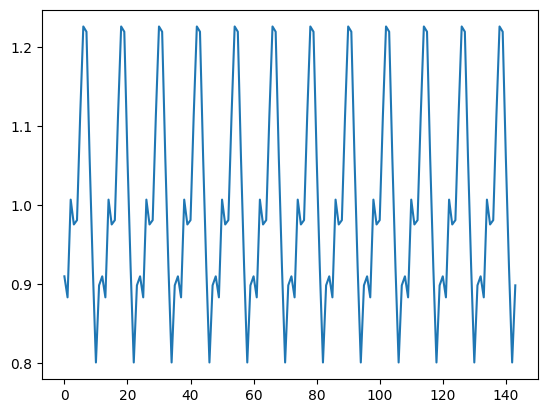

In [9]:
decompose.seasonal.plot()

In [10]:
trend = decompose.trend
seasonal = decompose.seasonal
residual = decompose.resid

In [11]:
# Split the data into tranings and testing sets
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]

In [12]:
# Fit a simple linear regression model on the training set
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(train.index.values.reshape(-1,1), train['Passengers'])

LinearRegression()

In [13]:
# Make prediction on the testing set
predictions = model.predict(test.index.values.reshape(-1,1))

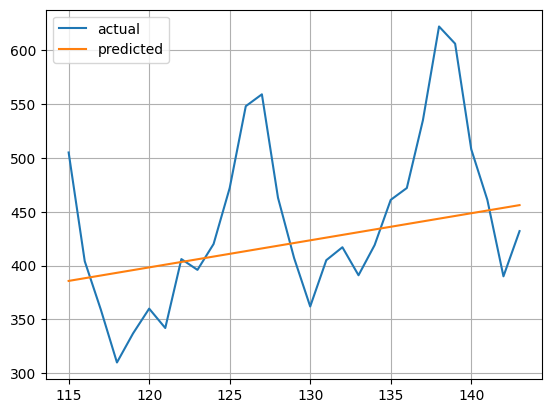

In [15]:
# Plot the actual and predicted values
plt.plot(test.index, test['Passengers'], label='actual')
plt.plot(test.index, predictions, label='predicted')
plt.legend()
plt.grid()
plt.show()